# Hamburg Bike Count Stations — One-Year Time-Series

Fetches **daily and 5-minute bike count time-series** for all Hamburg infrared sensor stations,
covering **1 April 2025 → 31 March 2026** (one full year).

| Source | Service | Layer | Stations | Resolution |
|--------|---------|-------|----------|------------|
| IoT Hamburg STA | `HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren` | `Anzahl_Fahrraeder_Zaehlstelle_1-Tag` | ~87 | Daily |
| IoT Hamburg STA | `HH_STA_HamburgerRadzaehlnetz` | `Anzahl_Fahrraeder_Zaehlfeld_5-Min` | 4 | 5-minute |

**Excluded:** StadtRAD (`HH_STA_StadtRad`) — bike-sharing dock occupancy, not a flow sensor.

**Outputs:**
- `hamburg_bike_timeseries.csv` — long-format time-series (all stations, all dates)
- `hamburg_bike_timeseries_chart.png` — line chart of the most-frequently-measured station

In [1]:
import subprocess, sys
pkgs = ["requests", "pandas", "matplotlib"]
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs, check=True)
print("✓ Packages ready")

✓ Packages ready


In [1]:
import requests, pandas as pd, json, time, warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path
warnings.filterwarnings('ignore')

STA_BASE   = "https://iot.hamburg.de/v1.1"
TIMEOUT    = 30
OBS_PAGE   = 500          # max observations per API page
DS_PAGE    = 100          # datastreams per page

# ── Date range: 1 April 2025 – 31 March 2026 ────────────────────────────────
DATE_FROM  = "2025-01-01T00:00:00.000Z"
DATE_TO    = "2026-04-27T15:35:00.000Z"

# ── Bike sensor services (StadtRAD excluded) ─────────────────────────────────
SERVICES = [
    {"service": "HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren",
     "layer"  : "Anzahl_Fahrraeder_Zaehlstelle_1-Tag",
     "label"  : "Infrared daily",
     "freq"   : "1D"},
    {"service": "HH_STA_HamburgerRadzaehlnetz",
     "layer"  : "Anzahl_Fahrraeder_Zaehlfeld_5-Min",
     "label"  : "Radzählnetz 5-min",
     "freq"   : "5min"},
]

print(f"Date range : {DATE_FROM[:10]}  →  {DATE_TO[:10]}")
print(f"Services   : {len(SERVICES)}")

Date range : 2025-01-01  →  2026-04-27
Services   : 2


## 1 · Helpers

In [2]:
def get_all_pages(url, session=None, retries=3, backoff=(10, 30, 60)):
    """Follow @iot.nextLink paging; return all items collected so far.

    On a connection error or timeout for any page:
      - retries up to `retries` times with waits from `backoff`
      - if all retries fail: logs the error, returns whatever was
        collected before the failure (partial data is kept)
      - never raises — the caller decides what to do with partial results
    """
    sess   = session or requests.Session()
    items  = []
    page   = 0

    while url:
        last_exc = None
        for attempt in range(1, retries + 1):
            try:
                r = sess.get(url, timeout=TIMEOUT)
                r.raise_for_status()
                data  = r.json()
                batch = data.get("value", [])
                items.extend(batch)
                url   = data.get("@iot.nextLink")
                page += 1
                last_exc = None
                break                          # success — move to next page
            except (requests.exceptions.ConnectionError,
                    requests.exceptions.Timeout,
                    requests.exceptions.ReadTimeout,
                    requests.exceptions.ChunkedEncodingError,
                    requests.exceptions.HTTPError) as exc:
                last_exc = exc
                wait = backoff[min(attempt - 1, len(backoff) - 1)]
                print(f"\n    ⚠ page {page+1} attempt {attempt}/{retries} failed: "
                      f"{type(exc).__name__}: {exc}")
                if attempt < retries:
                    print(f"      waiting {wait}s before retry …")
                    time.sleep(wait)
            except Exception as exc:
                last_exc = exc
                print(f"\n    ⚠ page {page+1} unexpected error: "
                      f"{type(exc).__name__}: {exc}")
                break                          # non-network error, don't retry

        if last_exc is not None:
            # All retries exhausted (or non-retryable error).
            # Return partial data collected so far — raise a sentinel so
            # fetch_observations can signal the partial-failure to its caller.
            print(f"    ✗ Giving up on page {page+1}. "
                  f"Returning {len(items):,} items collected before failure.")
            raise _PartialFetch(items, last_exc)

    return items


class _PartialFetch(Exception):
    """Raised by get_all_pages when paging aborts mid-way.
    Carries .items (partial result) and .cause (original exception)."""
    def __init__(self, items, cause):
        self.items = items
        self.cause = cause
        super().__init__(str(cause))


def extract_coords(thing):
    for loc in thing.get("Locations", []):
        g = loc.get("location", {})
        c = (g.get("coordinates")
             if g.get("type") == "Point"
             else g.get("geometry", {}).get("coordinates"))
        if c and len(c) >= 2:
            return float(c[0]), float(c[1])
    return None, None


def parse_phenomenon_time(pt_str):
    """Return the START timestamp from either 'ts' or 'ts/ts' STA format."""
    if not pt_str:
        return None
    ts = pt_str.split("/")[0]
    return pd.to_datetime(ts, utc=True)


def fetch_observations(ds_id, date_from, date_to, session):
    """Fetch all observations for one datastream in the date range.

    Returns (obs_list, is_complete) where:
      obs_list    — list of observation dicts (may be partial on network error)
      is_complete — True if all pages were fetched, False if aborted early
    """
    url = (
        f"{STA_BASE}/Datastreams({ds_id})/Observations"
        f"?$filter=phenomenonTime ge {date_from}"
        f" and phenomenonTime le {date_to}"
        f"&$orderby=phenomenonTime asc"
        f"&$select=phenomenonTime,result"
        f"&$top={OBS_PAGE}"
    )
    try:
        obs = get_all_pages(url, session)
        return obs, True
    except _PartialFetch as pf:
        return pf.items, False     # partial data, caller will flag as incomplete
    except Exception as exc:
        print(f"    ✗ fetch_observations failed entirely: {type(exc).__name__}: {exc}")
        return [], False


print("✓ Helpers defined (get_all_pages: retry ×3 with backoff 10/30/60 s)")


✓ Helpers defined (get_all_pages: retry ×3 with backoff 10/30/60 s)


## 2 · Fetch Station Metadata

Discover all datastream IDs, names, and coordinates for both services.

In [3]:
sess = requests.Session()
all_meta = []   # one dict per datastream

for svc in SERVICES:
    print(f"Fetching metadata: {svc['service']} / {svc['layer']} …")
    url = (
        f"{STA_BASE}/Datastreams"
        f"?$filter=properties/serviceName eq '{svc['service']}'"
        f" and properties/layerName eq '{svc['layer']}'"
        f"&$expand=Thing($expand=Locations($select=location))"
        f"&$select=@iot.id,name,phenomenonTime,unitOfMeasurement,properties"
        f"&$top={DS_PAGE}"
    )
    ds_list = get_all_pages(url, sess)
    print(f"  → {len(ds_list)} datastreams")

    for ds in ds_list:
        thing = ds.get("Thing", {})
        lon, lat = extract_coords(thing)
        pt = ds.get("phenomenonTime", "")
        parts = pt.split("/") if "/" in pt else [pt, pt]
        all_meta.append({
            "datastream_id"   : str(ds["@iot.id"]),
            "station_id"      : str(thing.get("@iot.id", "")),
            "station_name"    : thing.get("name", "").strip(),
            "service_name"    : svc["service"],
            "layer_name"      : svc["layer"],
            "label"           : svc["label"],
            "native_freq"     : svc["freq"],
            "longitude_wgs84" : lon,
            "latitude_wgs84"  : lat,
            "data_start"      : parts[0] if parts[0] else None,
            "data_end"        : parts[-1] if parts[-1] else None,
            "unit"            : ds.get("unitOfMeasurement", {}).get("symbol", ""),
        })

df_meta = pd.DataFrame(all_meta)
print(f"\n✓ Total datastreams: {len(df_meta)}")
print(df_meta.groupby(["service_name","layer_name"]).size().to_string())
df_meta.head()

Fetching metadata: HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren / Anzahl_Fahrraeder_Zaehlstelle_1-Tag …
  → 313 datastreams
Fetching metadata: HH_STA_HamburgerRadzaehlnetz / Anzahl_Fahrraeder_Zaehlfeld_5-Min …
  → 359 datastreams

✓ Total datastreams: 672
service_name                                 layer_name                         
HH_STA_HamburgerRadzaehlnetz                 Anzahl_Fahrraeder_Zaehlfeld_5-Min      359
HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren  Anzahl_Fahrraeder_Zaehlstelle_1-Tag    313


,datastream_id,station_id,station_name,service_name,layer_name,label,native_freq,longitude_wgs84,latitude_wgs84,data_start,data_end,unit
0,35728,12077,Verkehrszählstelle 6655960,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,Infrared daily,1D,10.042419,53.597822,2020-11-15T23:00:00Z,2026-04-29T21:59:59Z,
1,32739,12091,Verkehrszählstelle 7433952,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,Infrared daily,1D,9.972782,53.581487,2020-01-10T23:00:00Z,2026-04-29T21:59:59Z,
2,26391,12105,Verkehrszählstelle 0311952,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,Infrared daily,1D,10.036414,53.574649,2020-08-11T22:00:00Z,2026-04-29T21:59:59Z,
3,26403,12128,Verkehrszählstelle 7197951,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,Infrared daily,1D,10.108526,53.536967,2024-09-11T22:00:00Z,2026-04-29T21:59:59Z,
4,27566,12130,Verkehrszählstelle 0311911,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,Infrared daily,1D,10.034132,53.575855,2020-07-28T22:00:00Z,2026-04-29T21:59:59Z,


## 3 · Fetch Daily Bike Counts — All Infrared Stations

Fetches one observation per day per station for the full year.
87 stations × ~365 days ≈ 31,755 rows. Estimated time: **~2–3 minutes**.

In [4]:
daily_meta  = df_meta[df_meta["native_freq"] == "1D"].copy()
daily_rows  = []
total       = len(daily_meta)
failed_daily = []    # stations skipped due to network errors

print(f"Fetching daily observations for {total} infrared stations …")
print(f"Date range: {DATE_FROM[:10]} → {DATE_TO[:10]}\n")

for i, (_, row) in enumerate(daily_meta.iterrows()):
    try:
        obs, complete = fetch_observations(
            row["datastream_id"], DATE_FROM, DATE_TO, sess
        )
        if not complete:
            print(f"  ⚠  [{i+1}/{total}] {row['station_name']!r}: "
                  f"partial data ({len(obs)} obs) — kept")
        for o in obs:
            ts = parse_phenomenon_time(o.get("phenomenonTime"))
            if ts is None:
                continue
            daily_rows.append({
                "datastream_id"   : row["datastream_id"],
                "station_id"      : row["station_id"],
                "station_name"    : row["station_name"],
                "service_name"    : row["service_name"],
                "layer_name"      : row["layer_name"],
                "longitude_wgs84" : row["longitude_wgs84"],
                "latitude_wgs84"  : row["latitude_wgs84"],
                "phenomenon_time" : ts,
                "bike_count"      : o.get("result"),
            })
    except Exception as exc:
        # Unexpected error not caught inside fetch_observations — skip station
        print(f"  ✗  [{i+1}/{total}] {row['station_name']!r} — "
              f"unexpected error, skipping: {type(exc).__name__}: {exc}")
        failed_daily.append({"station_name": row["station_name"],
                              "datastream_id": row["datastream_id"],
                              "error": str(exc)})
    if (i + 1) % 10 == 0 or i + 1 == total:
        print(f"  {i+1}/{total} done ({len(daily_rows):,} rows)", end="\r")
    time.sleep(0.05)

df_daily = pd.DataFrame(daily_rows)
if len(df_daily):
    df_daily["bike_count"] = pd.to_numeric(df_daily["bike_count"], errors="coerce")

print(f"\n✓ Daily data : {len(df_daily):,} rows  |  "
      f"{df_daily['station_name'].nunique() if len(df_daily) else 0} stations")
if failed_daily:
    print(f"  ✗ {len(failed_daily)} station(s) skipped due to network errors:")
    for f_ in failed_daily:
        print(f"    {f_['station_name']!r}  — {f_['error'][:80]}")
df_daily.head()


Fetching daily observations for 313 infrared stations …
Date range: 2025-01-01 → 2026-04-27

  313/313 done (143,550 rows)
✓ Daily data : 143,550 rows  |  313 stations


,datastream_id,station_id,station_name,service_name,layer_name,longitude_wgs84,latitude_wgs84,phenomenon_time,bike_count
0,35728,12077,Verkehrszählstelle 6655960,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,10.042419,53.597822,2025-01-01 23:00:00+00:00,635
1,35728,12077,Verkehrszählstelle 6655960,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,10.042419,53.597822,2025-01-02 23:00:00+00:00,361
2,35728,12077,Verkehrszählstelle 6655960,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,10.042419,53.597822,2025-01-03 23:00:00+00:00,266
3,35728,12077,Verkehrszählstelle 6655960,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,10.042419,53.597822,2025-01-04 23:00:00+00:00,210
4,35728,12077,Verkehrszählstelle 6655960,HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren,Anzahl_Fahrraeder_Zaehlstelle_1-Tag,10.042419,53.597822,2025-01-05 23:00:00+00:00,735


## 4 · Fetch 5-Minute Bike Counts — Official Radzählnetz

`HH_STA_HamburgerRadzaehlnetz` provides the highest-resolution data: one reading every 5 minutes.

4 stations × ~105,120 readings/year ≈ **420,000 rows**. Estimated time: **~3–5 minutes**.

In [5]:
# ── Step 1: probe every 5-min station — count observations in date range ─────
# $count=true&$top=0 returns only the count integer, no observation payload.
# Each probe is individually try/except'd — a failed probe is logged and skipped.

TOP_N  = 30     # max stations to fully fetch per run
OFFSET = 0      # set > 0 to skip the first N ranked stations (resume offset)

fivemin_meta = df_meta[df_meta["native_freq"] == "5min"].copy()
total5       = len(fivemin_meta)
probe_results   = []   # (row, obs_count)
probe_failed    = []   # stations where probe itself errored

print(f"Phase 1 — probing {total5} 5-min stations for data availability …")
print(f"Date range: {DATE_FROM[:10]} → {DATE_TO[:10]}\n")

for i, (_, row) in enumerate(fivemin_meta.iterrows()):
    probe_url = (
        f"{STA_BASE}/Datastreams({row['datastream_id']})/Observations"
        f"?$filter=phenomenonTime ge {DATE_FROM}"
        f" and phenomenonTime le {DATE_TO}"
        f"&$count=true&$top=0"
    )
    try:
        r = sess.get(probe_url, timeout=TIMEOUT)
        r.raise_for_status()
        obs_count = r.json().get("@iot.count", 0) or 0
        status = f"{obs_count:>8,} obs" if obs_count > 0 else "    no data"
        print(f"  [{i+1}/{total5}] {row['station_name']!r:42s}  {status}")
        if obs_count > 0:
            probe_results.append((row.copy(), int(obs_count)))
    except (requests.exceptions.ConnectionError,
            requests.exceptions.Timeout,
            requests.exceptions.ReadTimeout,
            requests.exceptions.HTTPError) as exc:
        print(f"  [{i+1}/{total5}] {row['station_name']!r:42s}  "
              f"⚠ probe error (skipped): {type(exc).__name__}")
        probe_failed.append({"station_name": row["station_name"],
                              "datastream_id": row["datastream_id"],
                              "error": str(exc)})
    except Exception as exc:
        print(f"  [{i+1}/{total5}] {row['station_name']!r:42s}  "
              f"⚠ unexpected probe error (skipped): {type(exc).__name__}: {exc}")
        probe_failed.append({"station_name": row["station_name"],
                              "datastream_id": row["datastream_id"],
                              "error": str(exc)})
    time.sleep(0.05)

# ── Step 2: sort by (obs_count DESC, station_name ASC), save CSV, select top N ─
# Primary sort  : obs_count descending  — most data first
# Secondary sort: station_name ascending — alphabetical tie-break for equal counts
probe_results.sort(key=lambda x: (-x[1], x[0]["station_name"]))

# ── Save full probe_results to CSV before selecting ───────────────────────────
probe_csv = Path("hamburg_bike_probe_results.csv")
df_probe = pd.DataFrame([
    {
        "rank"            : rank,
        "station_name"    : row["station_name"],
        "datastream_id"   : row["datastream_id"],
        "station_id"      : row["station_id"],
        "service_name"    : row["service_name"],
        "layer_name"      : row["layer_name"],
        "longitude_wgs84" : row["longitude_wgs84"],
        "latitude_wgs84"  : row["latitude_wgs84"],
        "obs_count"       : cnt,
    }
    for rank, (row, cnt) in enumerate(probe_results, 1)
])
df_probe.to_csv(probe_csv, index=False, encoding="utf-8-sig")
print(f"\n✓ Probe results saved → {probe_csv.resolve()}")
print(f"  {len(df_probe):,} stations  |  sorted: obs_count DESC, station_name ASC")
print(df_probe[["rank", "station_name", "obs_count"]].head(20).to_string(index=False))

# ── Select window: OFFSET → OFFSET + TOP_N ────────────────────────────────────
top15 = probe_results[OFFSET : OFFSET + TOP_N]

print(f"\n{'─'*58}")
print(f"Stations with data       : {len(probe_results)} / {total5}")
print(f"Probe errors (skipped)   : {len(probe_failed)}")
print(f"OFFSET                   : {OFFSET}")
print(f"Stations to fetch        : {len(top15)} (ranks #{OFFSET+1}–#{OFFSET+len(top15)})")
print(f"{'─'*58}")
for rank, (row, cnt) in enumerate(top15, OFFSET + 1):
    print(f"  #{rank:>3}  {row['station_name']!r:44s}  {cnt:>9,} obs")


# ── Step 3: full fetch for selected stations — skip on any network failure ─────
print(f"\nPhase 2 — fetching full time-series for {len(top15)} stations …\n")

fivemin_rows   = []
failed_5min    = []    # stations skipped due to irrecoverable errors
partial_5min   = []    # stations with partial data (fetch aborted mid-way)

for i, (row, expected_cnt) in enumerate(top15):
    label = f"[{i+1}/{len(top15)}] {row['station_name']!r}"
    print(f"  {label}  (expected ~{expected_cnt:,} obs) …", end=" ", flush=True)

    try:
        obs, is_complete = fetch_observations(
            row["datastream_id"], DATE_FROM, DATE_TO, sess
        )

        if not obs:
            # fetch_observations returned empty list after failing on first page
            print(f"0 obs (host did not respond — skipped)")
            failed_5min.append({"station_name": row["station_name"],
                                 "datastream_id": row["datastream_id"],
                                 "reason": "empty response after retries"})
            time.sleep(2)
            continue

        n_appended = 0
        for o in obs:
            ts = parse_phenomenon_time(o.get("phenomenonTime"))
            if ts is None:
                continue
            fivemin_rows.append({
                "datastream_id"   : row["datastream_id"],
                "station_id"      : row["station_id"],
                "station_name"    : row["station_name"],
                "service_name"    : row["service_name"],
                "layer_name"      : row["layer_name"],
                "longitude_wgs84" : row["longitude_wgs84"],
                "latitude_wgs84"  : row["latitude_wgs84"],
                "phenomenon_time" : ts,
                "bike_count"      : o.get("result"),
            })
            n_appended += 1

        if is_complete:
            print(f"{n_appended:,} obs fetched ✓")
        else:
            print(f"{n_appended:,} obs fetched ⚠ (partial — host stopped responding)")
            partial_5min.append({"station_name": row["station_name"],
                                  "datastream_id": row["datastream_id"],
                                  "obs_kept": n_appended,
                                  "obs_expected": expected_cnt})

    except Exception as exc:
        # Catch-all: unexpected error not handled inside fetch_observations
        print(f"SKIPPED — unexpected error: {type(exc).__name__}: {exc}")
        failed_5min.append({"station_name": row["station_name"],
                             "datastream_id": row["datastream_id"],
                             "reason": f"{type(exc).__name__}: {exc}"})

    time.sleep(0.1)

# ── Results summary ────────────────────────────────────────────────────────────
df_5min = pd.DataFrame(fivemin_rows)
if len(df_5min):
    df_5min["bike_count"] = pd.to_numeric(df_5min["bike_count"], errors="coerce")
    print(f"\n✓ 5-min data  : {len(df_5min):,} rows  |  "
          f"{df_5min['station_name'].nunique()} stations")
else:
    df_5min = pd.DataFrame(columns=df_daily.columns)
    print("\n⚠ No 5-min data returned.")

if partial_5min:
    print(f"\n  ⚠ {len(partial_5min)} station(s) with partial data (kept):")
    for p in partial_5min:
        pct = p['obs_kept'] / p['obs_expected'] * 100 if p['obs_expected'] else 0
        print(f"    {p['station_name']!r:44s}  "
              f"{p['obs_kept']:,}/{p['obs_expected']:,} obs ({pct:.0f}%)")

if failed_5min:
    print(f"\n  ✗ {len(failed_5min)} station(s) skipped (no data saved):")
    for f_ in failed_5min:
        print(f"    {f_['station_name']!r:44s}  — {f_['reason'][:70]}")

if probe_failed:
    print(f"\n  ✗ {len(probe_failed)} station(s) where probe itself failed:")
    for f_ in probe_failed:
        print(f"    {f_['station_name']!r:44s}  — {f_['error'][:70]}")

df_5min.head()


Phase 1 — probing 359 5-min stations for data availability …
Date range: 2025-01-01 → 2026-04-27

  [1/359] 'Zählfeld J_36.1_1_I (veraltet)'             121,200 obs
  [2/359] 'Zählfeld J_36.1_2_I (veraltet)'             109,500 obs
  [3/359] 'Zählfeld B_39.5_1_I (veraltet)'             113,100 obs
  [4/359] 'Zählfeld B_39.5_2_G (veraltet)'             109,700 obs
  [5/359] 'Zählfeld B_51.1_1_I (veraltet)'                no data
  [6/359] 'Zählfeld B_51.1_2_I (veraltet)'                no data
  [7/359] 'Zählfeld G_40.1_1_G (veraltet)'             129,900 obs
  [8/359] 'Zählfeld G_40.1_2_I (veraltet)'             115,500 obs
  [9/359] 'Zählfeld B_39.6_1_G (veraltet)'             111,600 obs
  [10/359] 'Zählfeld B_39.6_2_I (veraltet)'             112,000 obs
  [11/359] 'Zählfeld B_51.2_1_I (veraltet)'                no data
  [12/359] 'Zählfeld B_51.2_2_I (veraltet)'                no data
  [13/359] 'Zählfeld B_28.6_1_G (veraltet)'             103,900 obs
  [14/359] 'Zählfeld B_28.6_2_I

  [119/359] 'Zählfeld G_32.2_1_G (veraltet)'             140,300 obs
  [120/359] 'Zählfeld G_32.2_2_I (veraltet)'             111,600 obs
  [121/359] 'Zählfeld G_32.1_1_I (veraltet)'             114,200 obs
  [122/359] 'Zählfeld G_32.1_2_G (veraltet)'             127,100 obs
  [123/359] 'Zählfeld G_40.2_1_I (veraltet)'             120,500 obs
  [124/359] 'Zählfeld G_40.2_2_G (veraltet)'             128,400 obs
  [125/359] 'Zählfeld A_1.3_1_G (veraltet)'              118,400 obs
  [126/359] 'Zählfeld A_1.3_2_I (veraltet)'              128,800 obs
  [127/359] 'Zählfeld D_40.4_1_G (veraltet)'             129,300 obs
  [128/359] 'Zählfeld D_40.4_2_I (veraltet)'             105,100 obs
  [129/359] 'Zählfeld A_25.2_1_G (veraltet)'             114,900 obs
  [130/359] 'Zählfeld A_25.2_2_I (veraltet)'             118,300 obs
  [131/359] 'Zählfeld D_40.5_1_I (veraltet)'             126,700 obs
  [132/359] 'Zählfeld D_40.5_2_G (veraltet)'             121,400 obs
  [133/359] 'Zählfeld D_6.2_2_G (v

  [238/359] 'Zählfeld D_57.2_2_I (veraltet)'             132,700 obs
  [239/359] 'Zählfeld B_49.1_1_I (veraltet)'             100,000 obs
  [240/359] 'Zählfeld B_49.1_2_I (veraltet)'             137,500 obs
  [241/359] 'Zählfeld J_79.1_1_I (veraltet)'             120,900 obs
  [242/359] 'Zählfeld J_79.1_2_I (veraltet)'             116,200 obs
  [243/359] 'Zählfeld J_63.1_1_I (veraltet)'             102,900 obs
  [244/359] 'Zählfeld J_63.1_2_I (veraltet)'             134,400 obs
  [245/359] 'Zählfeld D_72.1_2_I (veraltet)'             112,300 obs
  [246/359] 'Zählfeld D_73.1_2_I (veraltet)'             106,400 obs
  [247/359] 'Zählfeld D_73.2_1_I (veraltet)'             133,900 obs
  [248/359] 'Zählfeld J_77.1_1_I (veraltet)'             112,600 obs
  [249/359] 'Zählfeld J_77.1_2_I (veraltet)'             125,800 obs
  [250/359] 'Zählfeld B_46.6_1_G (veraltet)'             109,600 obs
  [251/359] 'Zählfeld B_46.6_2_I (veraltet)'             131,900 obs
  [252/359] 'Zählfeld B_66.1_1_G (

  [357/359] 'Zählfeld D_6.2_1_I (veraltet)'               23,904 obs
  [358/359] 'Zählfeld J_87.1_1_I (veraltet)'              59,277 obs
  [359/359] 'Zählfeld J_87.1_2_I (veraltet)'              59,277 obs

✓ Probe results saved → /Users/ariel/Downloads/hamburg_bike_probe_results.csv
  328 stations  |  sorted: obs_count DESC, station_name ASC
 rank                   station_name  obs_count
    1 Zählfeld B_34.2_2_I (veraltet)     168600
    2  Zählfeld B_9.4_1_G (veraltet)     162500
    3  Zählfeld B_8.1_2_I (veraltet)     156900
    4 Zählfeld B_41.3_2_I (veraltet)     156100
    5 Zählfeld B_41.3_1_I (veraltet)     152900
    6 Zählfeld G_46.3_1_G (veraltet)     151000
    7  Zählfeld B_8.1_1_I (veraltet)     150200
    8 Zählfeld B_17.2_1_I (veraltet)     149400
    9  Zählfeld B_9.2_2_G (veraltet)     149100
   10 Zählfeld J_47.1_1_I (veraltet)     147900
   11 Zählfeld A_38.2_1_I (veraltet)     146900
   12 Zählfeld A_43.2_2_G (veraltet)     146900
   13 Zählfeld A_70.1_2_I (ver

,datastream_id,station_id,station_name,service_name,layer_name,longitude_wgs84,latitude_wgs84,phenomenon_time,bike_count
0,17473,8102,Zählfeld B_34.2_2_I (veraltet),HH_STA_HamburgerRadzaehlnetz,Anzahl_Fahrraeder_Zaehlfeld_5-Min,9.932345,53.628547,2025-01-01 00:00:00+00:00,0
1,17473,8102,Zählfeld B_34.2_2_I (veraltet),HH_STA_HamburgerRadzaehlnetz,Anzahl_Fahrraeder_Zaehlfeld_5-Min,9.932345,53.628547,2025-01-01 00:05:00+00:00,1
2,17473,8102,Zählfeld B_34.2_2_I (veraltet),HH_STA_HamburgerRadzaehlnetz,Anzahl_Fahrraeder_Zaehlfeld_5-Min,9.932345,53.628547,2025-01-01 00:10:00+00:00,0
3,17473,8102,Zählfeld B_34.2_2_I (veraltet),HH_STA_HamburgerRadzaehlnetz,Anzahl_Fahrraeder_Zaehlfeld_5-Min,9.932345,53.628547,2025-01-01 00:15:00+00:00,0
4,17473,8102,Zählfeld B_34.2_2_I (veraltet),HH_STA_HamburgerRadzaehlnetz,Anzahl_Fahrraeder_Zaehlfeld_5-Min,9.932345,53.628547,2025-01-01 00:20:00+00:00,0


no data 31 stations, total 329 bike stations in Hamburg has data, every 5 mins.

## 4b · Continue Download — Stations Ranked #31+ from Probe CSV

Reads `hamburg_bike_probe_results.csv` (written by cell 4) and resumes from `OFFSET = 30`.
No re-probing needed — station metadata (datastream_id, coordinates, obs_count) is read
directly from the CSV. Results are appended to `df_5min` so **Section 5 requires no changes**.

In [5]:
# ── 4b · Read probe CSV and resume download from OFFSET = 30 ─────────────────
# Source  : hamburg_bike_probe_results.csv  (written by cell 4 / Step 2)
# OFFSET  : 30  → stations ranked #31 and beyond
# TOP_N_B : how many stations to fetch in this batch (default 15)
# Output  : rows appended to df_5min  →  Section 5 needs no changes

OFFSET_B  = 270    # start rank (0-based index, so rank #31 onward)
TOP_N_B   = 30    # stations to fetch in this batch
fivemin_rows   = []
df_5min = pd.DataFrame(fivemin_rows)
# ── Load probe CSV ────────────────────────────────────────────────────────────
probe_csv = Path("hamburg_bike_probe_results.csv")
if not probe_csv.exists():
    raise FileNotFoundError(
        f"{probe_csv} not found. Run cell 4 first to generate it."
    )

df_probe_b = pd.read_csv(probe_csv)
# CSV is already sorted: obs_count DESC, station_name ASC
print(f"✓ Probe CSV loaded: {len(df_probe_b):,} stations")
print(f"  Columns : {list(df_probe_b.columns)}")
print(f"  Offset  : {OFFSET_B}  →  fetching ranks "
      f"#{OFFSET_B+1}–#{OFFSET_B+TOP_N_B}")

# ── Select the batch window ───────────────────────────────────────────────────
batch_b = df_probe_b.iloc[OFFSET_B : OFFSET_B + TOP_N_B].copy()

if len(batch_b) == 0:
    print("⚠ No stations in this offset window. "
          "Reduce OFFSET_B or increase probe CSV size.")
else:
    # Skip any datastream_id already present in df_5min (from cell 4)
    existing_ds_ids = set(
        df_5min["datastream_id"].astype(str).unique()
    ) if isinstance(df_5min, pd.DataFrame) and len(df_5min) > 0 else set()

    batch_b["_ds_str"] = batch_b["datastream_id"].astype(str)
    skip_mask = batch_b["_ds_str"].isin(existing_ds_ids)
    skipped_b = batch_b[skip_mask]["station_name"].tolist()
    todo_b    = batch_b[~skip_mask].copy()
    batch_b.drop(columns=["_ds_str"], inplace=True)

    print(f"\n  Selected batch  : {len(batch_b)} stations")
    print(f"  Already in df_5min (skipped) : {len(skipped_b)}")
    for s in skipped_b:
        print(f"    ↩  {s!r}")
    print(f"  To fetch        : {len(todo_b)}")
    print(f"\n{'─'*60}")
    for _, r in todo_b.iterrows():
        print(f"  #{int(r['rank']):>3}  {r['station_name']!r:44s}  "
              f"{int(r['obs_count']):>9,} obs")
    print(f"{'─'*60}")

    # ── Fetch observations for each station in the batch ─────────────────────
    print(f"\nFetching 5-min time-series  "
          f"({DATE_FROM[:10]} → {DATE_TO[:10]}) …\n")

    extra_rows  = []
    failed_b    = []   # stations skipped (no data / error)
    partial_b   = []   # stations with partial data

    for i, (_, row) in enumerate(todo_b.iterrows()):
        expected_cnt = int(row["obs_count"])
        label = f"[{i+1}/{len(todo_b)}] {row['station_name']!r}"
        print(f"  {label}  (expected ~{expected_cnt:,} obs) …",
              end=" ", flush=True)

        try:
            obs, is_complete = fetch_observations(
                row["datastream_id"], DATE_FROM, DATE_TO, sess
            )

            if not obs:
                print("0 obs (host did not respond — skipped)")
                failed_b.append({"station_name"  : row["station_name"],
                                  "datastream_id" : row["datastream_id"],
                                  "reason"        : "empty response after retries"})
                time.sleep(2)
                continue

            n_appended = 0
            for o in obs:
                ts = parse_phenomenon_time(o.get("phenomenonTime"))
                if ts is None:
                    continue
                extra_rows.append({
                    "datastream_id"   : str(row["datastream_id"]),
                    "station_id"      : str(row["station_id"]),
                    "station_name"    : row["station_name"],
                    "service_name"    : row["service_name"],
                    "layer_name"      : row["layer_name"],
                    "longitude_wgs84" : row["longitude_wgs84"],
                    "latitude_wgs84"  : row["latitude_wgs84"],
                    "phenomenon_time" : ts,
                    "bike_count"      : o.get("result"),
                })
                n_appended += 1

            if is_complete:
                print(f"{n_appended:,} obs fetched ✓")
            else:
                print(f"{n_appended:,} obs fetched ⚠ (partial)")
                partial_b.append({"station_name"  : row["station_name"],
                                   "datastream_id" : row["datastream_id"],
                                   "obs_kept"      : n_appended,
                                   "obs_expected"  : expected_cnt})

        except Exception as exc:
            print(f"SKIPPED — {type(exc).__name__}: {exc}")
            failed_b.append({"station_name"  : row["station_name"],
                              "datastream_id" : row["datastream_id"],
                              "reason"        : f"{type(exc).__name__}: {exc}"})

        time.sleep(0.1)

    # ── Append extra rows to df_5min ──────────────────────────────────────────
    if extra_rows:
        df_5min_extra = pd.DataFrame(extra_rows)
        df_5min_extra["bike_count"] = pd.to_numeric(
            df_5min_extra["bike_count"], errors="coerce"
        )
        df_5min = pd.concat(
            [df_5min, df_5min_extra], ignore_index=True
        ) if isinstance(df_5min, pd.DataFrame) and len(df_5min) > 0 \
          else df_5min_extra

        print(f"\n✓ Batch 4b complete")
        print(f"  New rows added to df_5min  : {len(df_5min_extra):>10,}")
        print(f"  df_5min total rows now     : {len(df_5min):>10,}")
        print(f"  Unique stations in df_5min : {df_5min['station_name'].nunique():>10,}")
    else:
        print("\n⚠ No new rows fetched in batch 4b.")

    # ── Diagnostics ────────────────────────────────────────────────────────────
    if partial_b:
        print(f"\n  ⚠ {len(partial_b)} station(s) with partial data (kept):")
        for p in partial_b:
            pct = p['obs_kept'] / p['obs_expected'] * 100 \
                  if p['obs_expected'] else 0
            print(f"    {p['station_name']!r:44s}  "
                  f"{p['obs_kept']:,}/{p['obs_expected']:,} ({pct:.0f}%)")
    if failed_b:
        print(f"\n  ✗ {len(failed_b)} station(s) skipped:")
        for f_ in failed_b:
            print(f"    {f_['station_name']!r:44s}  {f_['reason'][:65]}")


✓ Probe CSV loaded: 328 stations
  Columns : ['rank', 'station_name', 'datastream_id', 'station_id', 'service_name', 'layer_name', 'longitude_wgs84', 'latitude_wgs84', 'obs_count']
  Offset  : 270  →  fetching ranks #271–#300

  Selected batch  : 30 stations
  Already in df_5min (skipped) : 0
  To fetch        : 30

────────────────────────────────────────────────────────────
  #271  'Zählfeld C_22.2_1_G (veraltet)'                107,800 obs
  #272  'Zählfeld B_10.2_2_I (veraltet)'                107,700 obs
  #273  'Zählfeld B_78.1_1_I (veraltet)'                107,600 obs
  #274  'Zählfeld A_64.1_2_I (veraltet)'                107,500 obs
  #275  'Zählfeld D_58.3_2_I (veraltet)'                107,300 obs
  #276  'Zählfeld J_60.1_2_I (veraltet)'                107,300 obs
  #277  'Zählfeld B_85.1_1_I (veraltet)'                107,100 obs
  #278  'Zählfeld B_9.5_2_I (veraltet)'                 106,900 obs
  #279  'Zählfeld D_24.2_1_I (veraltet)'                106,600 obs
  #280  '

## 5 · Combine All Sources → Save CSV

In [6]:
# Merge daily + 5-min into one long-format CSV
df_ts = pd.concat([df_daily, df_5min], ignore_index=True)
df_ts = df_ts.dropna(subset=["phenomenon_time"])
df_ts["phenomenon_time"] = pd.to_datetime(df_ts["phenomenon_time"], utc=True)
df_ts = df_ts.sort_values(["service_name", "station_name", "phenomenon_time"])
df_ts = df_ts.reset_index(drop=True)

out_csv = Path("hamburg_bike_timeseries.csv")
df_ts.to_csv(out_csv, index=False, encoding="utf-8-sig")

print(f"✓ Saved → {out_csv.resolve()}")
print(f"\n── Dataset summary ─────────────────────────────────")
print(f"  Total rows        : {len(df_ts):>10,}")
print(f"  Total stations    : {df_ts['station_name'].nunique():>10,}")
print(f"  Date range (min)  : {df_ts['phenomenon_time'].min()}")
print(f"  Date range (max)  : {df_ts['phenomenon_time'].max()}")
print(f"\n  Rows by source:")
print(df_ts.groupby(["service_name","layer_name"]).size()
         .rename("obs_count").reset_index().to_string(index=False))

print(f"\n── Data completeness (top 10 stations by obs count) ─")
obs_per_station = (
    df_ts.groupby(["station_name","service_name","layer_name"])
         .agg(obs_count=("bike_count","count"), mean_count=("bike_count","mean"))
         .sort_values("obs_count", ascending=False)
         .reset_index()
)
obs_per_station["mean_count"] = obs_per_station["mean_count"].round(1)
print(obs_per_station.head(10).to_string(index=False))

✓ Saved → /home/webapp/work/work/hamburg_bike_timeseries.csv

── Dataset summary ─────────────────────────────────
  Total rows        :  3,807,219
  Total stations    :        343
  Date range (min)  : 2025-01-01 00:00:00+00:00
  Date range (max)  : 2026-04-25 22:00:00+00:00

  Rows by source:
                               service_name                          layer_name  obs_count
               HH_STA_HamburgerRadzaehlnetz   Anzahl_Fahrraeder_Zaehlfeld_5-Min    3663669
HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren Anzahl_Fahrraeder_Zaehlstelle_1-Tag     143550

── Data completeness (top 10 stations by obs count) ─
                  station_name                 service_name                        layer_name  obs_count  mean_count
Zählfeld C_22.2_1_G (veraltet) HH_STA_HamburgerRadzaehlnetz Anzahl_Fahrraeder_Zaehlfeld_5-Min     122465         0.1
Zählfeld H_21.3_2_G (veraltet) HH_STA_HamburgerRadzaehlnetz Anzahl_Fahrraeder_Zaehlfeld_5-Min     122463         0.1
Zählfeld B_11.1_1_G (vera

## 6 · Identify the Most-Frequently-Measured Station

The station with the **highest number of observations** in the dataset has the finest temporal
resolution. For 5-minute Radzählnetz stations this reaches ~105,000 readings/year vs ~365 for
daily infrared stations.

In [7]:
# Rank stations by observation count
top_station = obs_per_station.iloc[0]

print("Most-frequently-measured station:")
print(f"  Name         : {top_station['station_name']}")
print(f"  Service      : {top_station['service_name']}")
print(f"  Layer        : {top_station['layer_name']}")
print(f"  Observations : {int(top_station['obs_count']):,}")
print(f"  Mean count   : {top_station['mean_count']}")

# Pull the full time-series for this station
mask_top = (
    (df_ts["station_name"]  == top_station["station_name"]) &
    (df_ts["service_name"]  == top_station["service_name"]) &
    (df_ts["layer_name"]    == top_station["layer_name"])
)
df_top = df_ts[mask_top].copy().sort_values("phenomenon_time")
df_top = df_top.set_index("phenomenon_time")
df_top.index = pd.to_datetime(df_top.index, utc=True)
df_top["bike_count"] = pd.to_numeric(df_top["bike_count"], errors="coerce")

native_freq = top_station["layer_name"]
is_5min = "5-Min" in native_freq
print(f"\n  Native frequency : {'5-minute' if is_5min else 'daily'}")
print(f"  Date range       : {df_top.index.min().date()} → {df_top.index.max().date()}")
df_top[["station_name","bike_count"]].head()

Most-frequently-measured station:
  Name         : Zählfeld C_22.2_1_G (veraltet)
  Service      : HH_STA_HamburgerRadzaehlnetz
  Layer        : Anzahl_Fahrraeder_Zaehlfeld_5-Min
  Observations : 122,465
  Mean count   : 0.1

  Native frequency : 5-minute
  Date range       : 2025-01-01 → 2026-03-02


,station_name,bike_count
phenomenon_time,,
2025-01-01 00:00:00+00:00,Zählfeld C_22.2_1_G (veraltet),0
2025-01-01 00:05:00+00:00,Zählfeld C_22.2_1_G (veraltet),0
2025-01-01 00:10:00+00:00,Zählfeld C_22.2_1_G (veraltet),0
2025-01-01 00:15:00+00:00,Zählfeld C_22.2_1_G (veraltet),0
2025-01-01 00:20:00+00:00,Zählfeld C_22.2_1_G (veraltet),0


## 7 · Prepare Chart Data

- If the station has **5-minute** data: aggregate to daily sums for the main line,
  keep a 7-day rolling mean as a smoothed overlay.
- If the station has **daily** data: use directly, add 4-week rolling mean.

In [ ]:
# ── Resample to daily ────────────────────────────────────────────────────────
if is_5min:
    # 5-min → daily total bikes counted in each day
    daily_series = df_top["bike_count"].resample("1D").sum(min_count=1)
    roll_window  = 7     # 7-day rolling mean
    freq_label   = "5-min data, aggregated to daily totals"
else:
    daily_series = df_top["bike_count"].resample("1D").mean()
    roll_window  = 28    # 4-week rolling mean
    freq_label   = "Daily station counts"

rolling_mean = daily_series.rolling(roll_window, center=True, min_periods=3).mean()

# ── Monthly aggregates for annotations ───────────────────────────────────────
monthly_mean = daily_series.resample("MS").mean().round(1)

# ── Overall stats ─────────────────────────────────────────────────────────────
total_obs_year = daily_series.sum()
peak_day       = daily_series.idxmax()
peak_val       = daily_series.max()
min_day        = daily_series.idxmin()
min_val        = daily_series.min()

print(f"Station  : {top_station['station_name']}")
print(f"Period   : {daily_series.index.min().date()} → {daily_series.index.max().date()}")
print(f"Total    : {total_obs_year:,.0f} bikes counted over the year")
print(f"Peak day : {peak_day.date()}  →  {peak_val:,.0f} bikes")
print(f"Min day  : {min_day.date()}   →  {min_val:,.0f} bikes")
print(f"\nMonthly averages:")
print(monthly_mean.to_string())

Station  : Zählfeld A_25.1_2_G (veraltet)
Period   : 2025-04-01 → 2026-03-02
Total    : 300,715 bikes counted over the year
Peak day : 2025-06-17  →  2,406 bikes
Min day  : 2026-01-04   →  1 bikes

Monthly averages:
phenomenon_time
2025-04-01 00:00:00+00:00    1366.2
2025-05-01 00:00:00+00:00    1428.8
2025-06-01 00:00:00+00:00    1471.1
2025-07-01 00:00:00+00:00    1184.0
2025-08-01 00:00:00+00:00     727.9
2025-09-01 00:00:00+00:00     432.8
2025-10-01 00:00:00+00:00     669.1
2025-11-01 00:00:00+00:00     859.8
2025-12-01 00:00:00+00:00     681.5
2026-01-01 00:00:00+00:00     312.2
2026-02-01 00:00:00+00:00     741.1
2026-03-01 00:00:00+00:00     481.0
Freq: MS


## 8 · Line Chart — Most-Frequently-Measured Station

- **Grey bars**: daily bike count (primary data)
- **Orange line**: rolling mean (7-day for 5-min source, 28-day for daily source)
- **Blue circles**: monthly average markers
- Annotations mark peak and minimum days

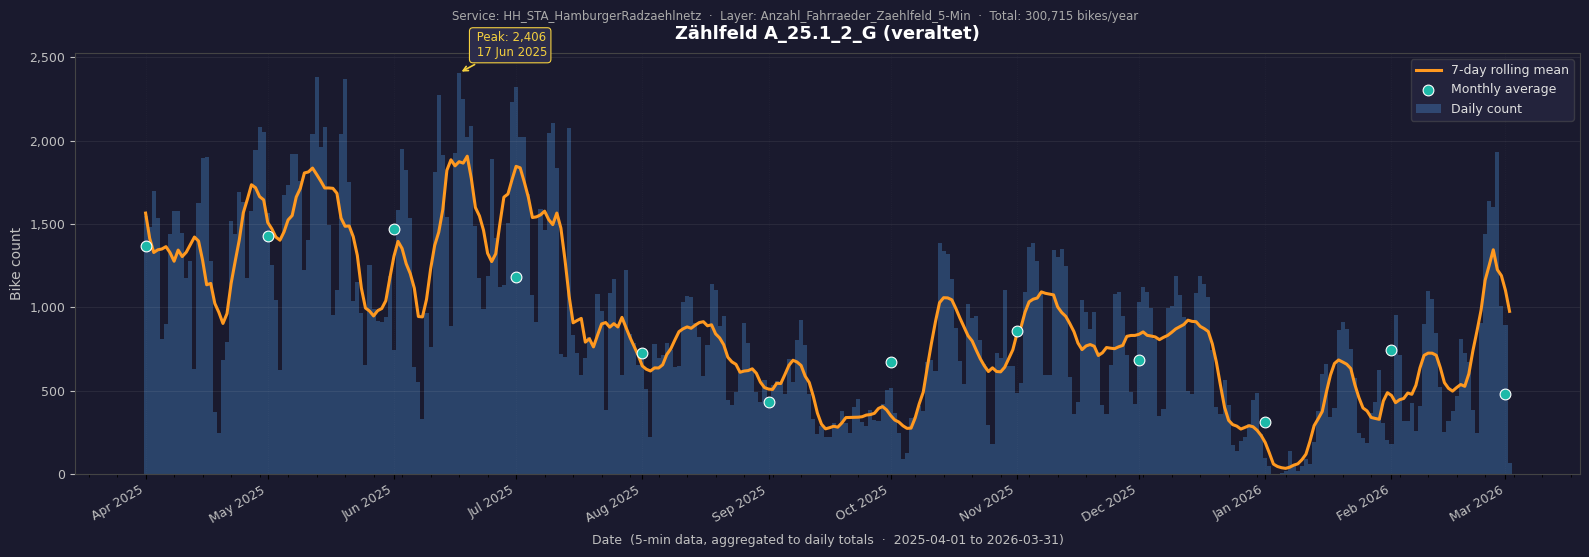

✓ Chart saved → /content/hamburg_bike_timeseries_chart.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

# ── Daily bars ────────────────────────────────────────────────────────────────
valid = daily_series.dropna()
ax.bar(valid.index, valid.values, color="#4a90d9", alpha=0.35, width=1.0,
       label="Daily count")

# ── Rolling mean line ─────────────────────────────────────────────────────────
roll_valid = rolling_mean.dropna()
ax.plot(roll_valid.index, roll_valid.values, color="#FF9920", linewidth=2.2,
        label=f"{roll_window}-day rolling mean", zorder=5)

# ── Monthly average markers ───────────────────────────────────────────────────
monthly_valid = monthly_mean.dropna()
ax.scatter(monthly_valid.index, monthly_valid.values, color="#1DB9A8",
           s=60, zorder=6, label="Monthly average", edgecolors="white", linewidths=0.8)

# ── Annotate peak ─────────────────────────────────────────────────────────────
ax.annotate(
    f" Peak: {peak_val:,.0f}\n {peak_day.strftime('%d %b %Y')}",
    xy=(peak_day, peak_val),
    xytext=(10, 12), textcoords="offset points",
    fontsize=8.5, color="#f4d03f",
    arrowprops=dict(arrowstyle="->", color="#f4d03f", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", fc="#2c2c4a", ec="#f4d03f", lw=0.8),
)

# ── X axis: monthly ticks ─────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator())
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9, color="#c0c0c0")

# ── Y axis ────────────────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))
ax.tick_params(axis='y', colors='#c0c0c0', labelsize=9)
ax.set_ylabel("Bike count", color="#c0c0c0", fontsize=10)

# ── Grid & spines ─────────────────────────────────────────────────────────────
ax.grid(axis='y', color='#ffffff', alpha=0.08, linewidth=0.6)
ax.grid(axis='x', color='#ffffff', alpha=0.05, linewidth=0.5, linestyle=':')
for spine in ax.spines.values():
    spine.set_edgecolor("#444")

# ── Legend ────────────────────────────────────────────────────────────────────
legend = ax.legend(loc='upper right', fontsize=9, framealpha=0.5,
                   facecolor='#2c2c4a', edgecolor='#555',
                   labelcolor='#e0e0e0')

# ── Titles ────────────────────────────────────────────────────────────────────
unit_str = top_station.get('unit', 'counts') if hasattr(top_station, 'get') else ''
ax.set_title(
    f"{top_station['station_name']}",
    color="#ffffff", fontsize=13, fontweight='bold', pad=10
)
ax.set_xlabel(
    f"Date  ({freq_label}  ·  {DATE_FROM[:10]} to {DATE_TO[:10]})",
    color="#c0c0c0", fontsize=9, labelpad=6
)

# ── Subtitle with stats ───────────────────────────────────────────────────────
fig.text(
    0.5, 0.92,
    f"Service: {top_station['service_name']}  ·  Layer: {top_station['layer_name']}  ·  "
    f"Total: {total_obs_year:,.0f} bikes/year",
    ha='center', va='top', color='#aaaaaa', fontsize=8.5
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
chart_out = Path("hamburg_bike_timeseries_chart.png")
plt.savefig(chart_out, dpi=160, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"✓ Chart saved → {chart_out.resolve()}")

## 9 · Multi-Station Overview — All Infrared Stations

Monthly average bike counts for all stations on one chart — shows spatial variation
in cycling activity across Hamburg.

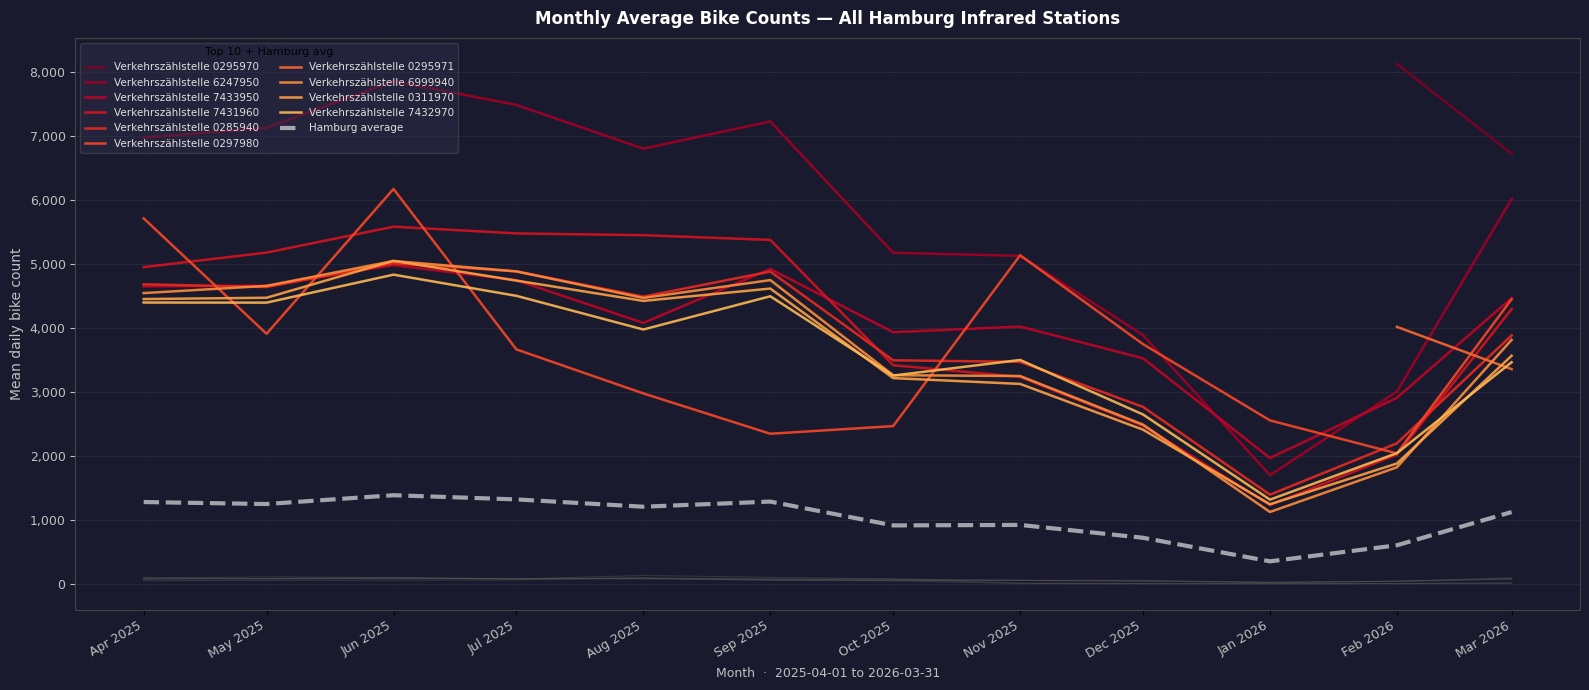

✓ Multi-station chart saved → /content/hamburg_bike_multistation_chart.png


In [ ]:
# Monthly aggregation for all daily infrared stations
df_daily_only = df_ts[df_ts["native_freq"] == "1D"].copy() \
    if "native_freq" in df_ts.columns \
    else df_ts[df_ts["layer_name"] == "Anzahl_Fahrraeder_Zaehlstelle_1-Tag"].copy()

if len(df_daily_only) == 0:
    df_daily_only = df_ts[df_ts["service_name"] == "HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren"].copy()

# Pivot to wide format: stations as columns, dates as rows
df_monthly = (
    df_daily_only
    .assign(month=lambda d: d["phenomenon_time"].dt.to_period("M"))
    .groupby(["month","station_name"])["bike_count"]
    .mean()
    .unstack("station_name")
)
df_monthly.index = df_monthly.index.to_timestamp()

# Compute annual mean per station for ranking
annual_mean = df_monthly.mean().sort_values(ascending=False)

# ── Plot: top 10 + bottom 5 stations ────────────────────────────────────────
top10    = annual_mean.head(10).index.tolist()
bottom5  = annual_mean.tail(5).index.tolist()
selected = top10 + bottom5

fig2, ax2 = plt.subplots(figsize=(16, 7))
fig2.patch.set_facecolor("#1a1a2e")
ax2.set_facecolor("#1a1a2e")

# Use a colour gradient from teal (busiest) to grey (quietest)
import matplotlib.cm as cm
n = len(selected)
cmap = cm.get_cmap("YlOrRd", n)

for j, station in enumerate(selected):
    if station not in df_monthly.columns:
        continue
    series = df_monthly[station].dropna()
    is_top = station in top10
    color  = cmap(1 - j / (n - 1)) if is_top else "#555555"
    lw     = 1.8 if is_top else 0.8
    alpha  = 0.9 if is_top else 0.45
    label  = f"{station[:28]}" if is_top else None
    ax2.plot(series.index, series.values, linewidth=lw, alpha=alpha,
             color=color, label=label)

# Overall Hamburg average
hamburg_avg = df_monthly.mean(axis=1)
ax2.plot(hamburg_avg.index, hamburg_avg.values, linewidth=3,
         color="#ffffff", linestyle='--', alpha=0.6, label="Hamburg average")

ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right", fontsize=9, color='#c0c0c0')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax2.tick_params(axis='y', colors='#c0c0c0', labelsize=9)
ax2.set_ylabel("Mean daily bike count", color='#c0c0c0', fontsize=10)
ax2.grid(axis='y', color='#ffffff', alpha=0.07, linewidth=0.6)
ax2.grid(axis='x', color='#ffffff', alpha=0.04, linewidth=0.5, linestyle=':')
for s in ax2.spines.values(): s.set_edgecolor("#444")

legend2 = ax2.legend(loc='upper left', fontsize=7.5, framealpha=0.5,
                     facecolor='#2c2c4a', edgecolor='#555',
                     labelcolor='#e0e0e0', ncol=2, title="Top 10 + Hamburg avg",
                     title_fontsize=8)

ax2.set_title("Monthly Average Bike Counts — All Hamburg Infrared Stations",
              color='#ffffff', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel(f"Month  ·  {DATE_FROM[:10]} to {DATE_TO[:10]}",
               color='#c0c0c0', fontsize=9)

plt.tight_layout()
chart2_out = Path("hamburg_bike_multistation_chart.png")
plt.savefig(chart2_out, dpi=160, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print(f"✓ Multi-station chart saved → {chart2_out.resolve()}")

## 10 · Wide-Format Pivot Table (Optional)

Exports the daily infrared data as a wide CSV: one column per station, rows are dates.
Easier to compare stations side by side in Excel.

In [ ]:
# Pivot: daily infrared data only (daily resolution, all stations)
df_wide_src = df_ts[
    df_ts["layer_name"] == "Anzahl_Fahrraeder_Zaehlstelle_1-Tag"
].copy()

if len(df_wide_src):
    df_wide_src["date"] = df_wide_src["phenomenon_time"].dt.date
    df_wide = (
        df_wide_src.groupby(["date","station_name"])["bike_count"]
        .mean()
        .unstack("station_name")
        .round(1)
    )
    df_wide.index.name = "date"
    wide_out = Path("hamburg_bike_timeseries_wide.csv")
    df_wide.to_csv(wide_out, encoding="utf-8-sig")
    print(f"✓ Wide CSV: {df_wide.shape[0]} dates × {df_wide.shape[1]} stations")
    print(f"  Saved → {wide_out.resolve()}")
    df_wide.head()
else:
    print("No daily infrared data available for wide-format export.")

✓ Wide CSV: 364 dates × 312 stations
  Saved → /content/hamburg_bike_timeseries_wide.csv


## 11 · Annual Summary Statistics per Station

In [ ]:
summary = (
    df_ts[df_ts["layer_name"] == "Anzahl_Fahrraeder_Zaehlstelle_1-Tag"]
    .groupby("station_name")["bike_count"]
    .agg(
        obs_days        = "count",
        annual_total    = "sum",
        daily_mean      = "mean",
        daily_median    = "median",
        daily_max       = "max",
        daily_min       = "min",
        std             = "std",
    )
    .round(1)
    .sort_values("annual_total", ascending=False)
    .reset_index()
)

print(f"Annual statistics for {len(summary)} infrared stations:")
print(summary.to_string(index=False))

summary_out = Path("hamburg_bike_annual_summary.csv")
summary.to_csv(summary_out, index=False, encoding="utf-8-sig")
print(f"\n✓ Annual summary saved → {summary_out.resolve()}")

Annual statistics for 312 infrared stations:
              station_name  obs_days  annual_total  daily_mean  daily_median  daily_max  daily_min    std
Verkehrszählstelle 6247950       364       2076153      5703.7        5701.5      13936         63 3033.4
Verkehrszählstelle 7433950       364       1481578      4070.3        4406.0       8679        151 1594.7
Verkehrszählstelle 7431960       364       1478412      4061.6        4171.5      11130         86 2188.7
Verkehrszählstelle 0285940       364       1389642      3817.7        4037.0       6958        142 1675.4
Verkehrszählstelle 6999940       364       1339104      3678.9        3875.5       7187         81 1812.5
Verkehrszählstelle 0311970       364       1311183      3602.2        3621.0       7356        149 1773.9
Verkehrszählstelle 7432970       364       1299435      3569.9        3616.5       7193        164 1641.4
Verkehrszählstelle 0287980       364       1275943      3505.3        3344.0       8248          0 2521.9
V

---
## Output files

| File | Format | Contents |
|------|--------|----------|
| `hamburg_bike_timeseries.csv` | Long CSV | All observations — one row per (station, timestamp) |
| `hamburg_bike_timeseries_wide.csv` | Wide CSV | Infrared daily data — rows=dates, columns=stations |
| `hamburg_bike_annual_summary.csv` | Summary CSV | Per-station annual totals, mean, max, median |
| `hamburg_bike_timeseries_chart.png` | PNG | Line chart of most-frequently-measured station |
| `hamburg_bike_multistation_chart.png` | PNG | Monthly average all stations overview |

## CSV columns (`hamburg_bike_timeseries.csv`)

| Column | Description |
|--------|-------------|
| `datastream_id` | STA Datastream `@iot.id` |
| `station_id` | STA Thing `@iot.id` |
| `station_name` | Station name from STA |
| `service_name` | `HH_STA_Verkehrsdaten_Rad_Infrarotdetektoren` or `HH_STA_HamburgerRadzaehlnetz` |
| `layer_name` | `Anzahl_Fahrraeder_Zaehlstelle_1-Tag` or `Anzahl_Fahrraeder_Zaehlfeld_5-Min` |
| `longitude_wgs84` / `latitude_wgs84` | WGS84 station coordinates |
| `phenomenon_time` | Observation timestamp (UTC, start of interval) |
| `bike_count` | Bikes counted in this interval |

## Performance notes

| Section | API calls | Estimated time |
|---------|-----------|----------------|
| Metadata fetch | ~2 | < 5 s |
| Daily infrared (87 stations) | ~87 | ~2–3 min |
| 5-min Radzählnetz (4 stations) | ~840 pages | ~3–5 min |
| **Total** | **~930** | **~5–8 min** |